In [23]:
!pip install joblib

In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_curve, auc
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# ---------- Load wavelet features ----------
X = np.load("X_wavelet_features.npy")   # (N, F)
y = np.load("y_labels.npy")            # (N,)


In [25]:
print(X.shape, y.shape)

(101418, 30) (101418,)


In [6]:
# Train/val split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
# Standardize features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


In [8]:
# ---------- RandomForest ----------
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_s, y_train)
y_pred_rf = rf.predict(X_test_s)


print("RandomForest Results:")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

RandomForest Results:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     18120
           1       0.97      0.60      0.74       556
           2       0.93      0.88      0.91      1447
           3       0.88      0.45      0.59       161

    accuracy                           0.97     20284
   macro avg       0.94      0.73      0.81     20284
weighted avg       0.97      0.97      0.97     20284

Confusion Matrix:
 [[18046    11    62     1]
 [  223   331     2     0]
 [  162     0  1276     9]
 [   63     0    26    72]]


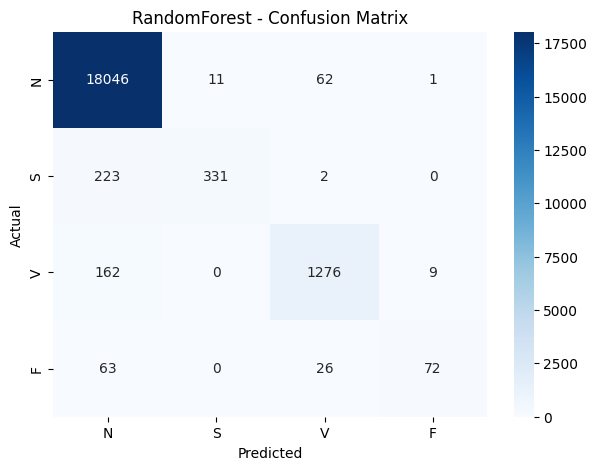

In [12]:
# Confusion Matrix RF
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(7,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['N','S','V','F'],
            yticklabels=['N','S','V','F'])
plt.title("RandomForest - Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

In [18]:
# ---------- SVM (RBF) ----------
svm = SVC(kernel="rbf", C=5, gamma="scale", probability=True)
svm.fit(X_train_s, y_train)
y_pred_svm = svm.predict(X_test_s)

print("\nSVM Results:")
print(classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))



SVM Results:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     18120
           1       0.91      0.62      0.74       556
           2       0.93      0.87      0.90      1447
           3       0.85      0.61      0.71       161

    accuracy                           0.97     20284
   macro avg       0.92      0.78      0.83     20284
weighted avg       0.97      0.97      0.97     20284

Confusion Matrix:
 [[18019    34    66     1]
 [  207   344     5     0]
 [  167     0  1263    17]
 [   41     0    21    99]]


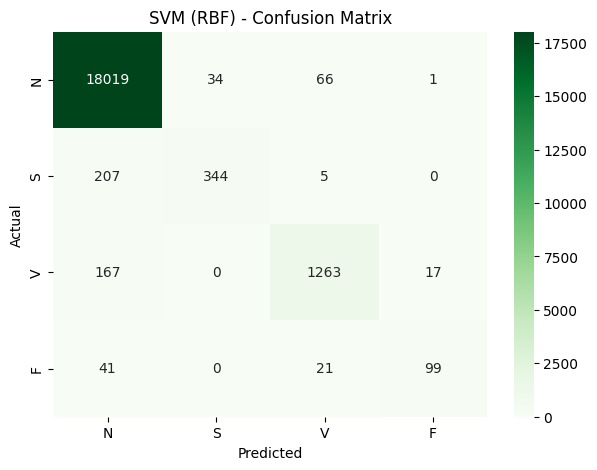

In [19]:
# Confusion Matrix SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(7,5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['N','S','V','F'],
            yticklabels=['N','S','V','F'])
plt.title("SVM (RBF) - Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

In [20]:
rf_acc = accuracy_score(y_test, y_pred_rf)
svm_acc = accuracy_score(y_test, y_pred_svm)

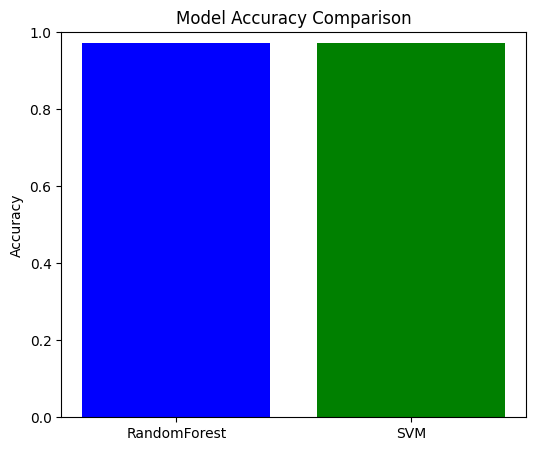

In [21]:
plt.figure(figsize=(6,5))
plt.bar(['RandomForest', 'SVM'], [rf_acc, svm_acc], color=['blue','green'])
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.show()

In [16]:
from sklearn.preprocessing import label_binarize

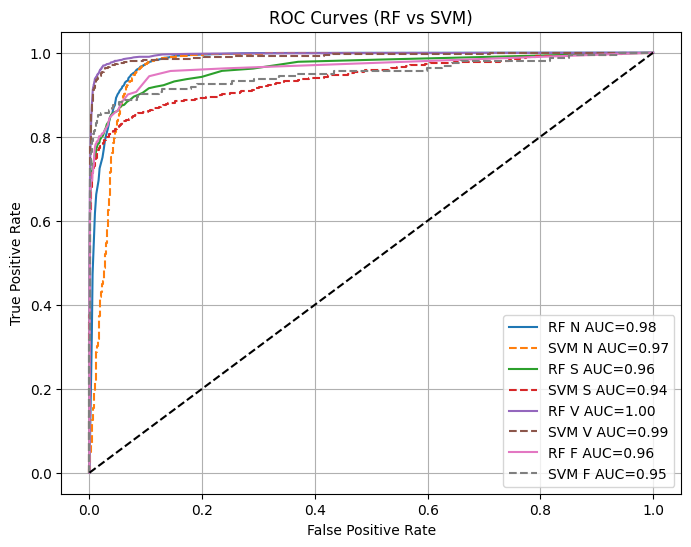

In [22]:
# Binarize labels for 4 classes
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])

# RF ROC
y_score_rf = rf.predict_proba(X_test_s)

# SVM ROC
y_score_svm = svm.predict_proba(X_test_s)

plt.figure(figsize=(8,6))
for i, cls in enumerate(['N','S','V','F']):
    fpr_rf, tpr_rf, _ = roc_curve(y_test_bin[:, i], y_score_rf[:, i])
    roc_auc_rf = auc(fpr_rf, tpr_rf)

    plt.plot(fpr_rf, tpr_rf, label=f'RF {cls} AUC={roc_auc_rf:.2f}')

    fpr_svm, tpr_svm, _ = roc_curve(y_test_bin[:, i], y_score_svm[:, i])
    roc_auc_svm = auc(fpr_svm, tpr_svm)

    plt.plot(fpr_svm, tpr_svm, linestyle='--', 
             label=f'SVM {cls} AUC={roc_auc_svm:.2f}')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (RF vs SVM)")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
import joblib

# Save RandomForest
joblib.dump(rf, "rf_model.pkl")

# Save SVM
joblib.dump(svm, "svm_model.pkl")

# Save Scaler (VERY IMPORTANT)
joblib.dump(scaler, "scaler.pkl")

print("Models saved successfully.")

Models saved successfully.
